In [9]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sns
from tqdm import tqdm
import os
from sklearn.metrics import f1_score, accuracy_score

# ---------------------- 1. 环境配置 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
        return False
    except: return False
set_chinese_font()

# ---------------------- 2. 核心对比模型：MSFF-LSTM ----------------------
class MSFF_LSTM(nn.Module):
    """
    保持与 Transformer 相同的 MSFF 前端和多任务后端
    仅将中间编码器替换为双层双向 LSTM
    """
    def __init__(self, input_dim=10, d_model=512, num_layers=2, horizon=10):
        super(MSFF_LSTM, self).__init__()
        self.horizon = horizon
        
        # 🟢 前端：多尺度特征提取 (MSFF)
        self.conv3 = nn.Conv1d(input_dim, d_model // 4, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(input_dim, d_model // 4, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(input_dim, d_model // 2, kernel_size=7, padding=3)
        self.bn = nn.BatchNorm1d(d_model)
        self.gelu = nn.GELU()
        
        # 🟢 中端：LSTM 编码器 (修正参数名为 input_size)
        # hidden_dim 设置为 d_model // 2，因为双向拼接后总维度为 d_model
        self.lstm = nn.LSTM(input_size=d_model, hidden_size=d_model // 2, 
                            num_layers=num_layers, batch_first=True, bidirectional=True)
        
        # 🟢 后端：多任务输出头 (与 Transformer 保持一致)
        self.head_horizon = nn.Sequential(
            nn.Linear(d_model, 512), 
            nn.GELU(), 
            nn.Linear(512, horizon * input_dim), 
            nn.Sigmoid()
        )
        self.head_type = nn.Sequential(
            nn.Linear(d_model * 2, 512), 
            nn.LayerNorm(512), 
            nn.GELU(),
            nn.Dropout(0.5), 
            nn.Linear(512, 256), 
            nn.GELU(), 
            nn.Linear(256, 5)
        )
        self.head_physics = nn.Linear(d_model, 2)

    def forward(self, x):
        # x: (Batch, 12, 10)
        x_in = x.permute(0, 2, 1) # -> (Batch, 10, 12)
        
        # MSFF 卷积提取
        x = torch.cat([self.conv3(x_in), self.conv5(x_in), self.conv7(x_in)], dim=1)
        x = self.gelu(self.bn(x)).permute(0, 2, 1) # -> (Batch, 12, 512)
        
        # LSTM 序列建模
        x, _ = self.lstm(x) # -> (Batch, 12, 512)
        
        # 全局池化特征
        avg_feat = torch.mean(x, dim=1)
        max_feat, _ = torch.max(x, dim=1)
        concat_feat = torch.cat([avg_feat, max_feat], dim=1) # -> (Batch, 1024)
        
        # 末端特征用于态势预测
        feat_last = x[:, -1, :] 
        
        return self.head_horizon(feat_last).view(-1, self.horizon, 10), \
               self.head_type(concat_feat), \
               self.head_physics(avg_feat)

# ---------------------- 3. 增强 Loss ----------------------
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(label_smoothing=0.1)
    def forward(self, input, target):
        logp = self.ce(input, target)
        p = torch.exp(-logp)
        return ((1 - p) ** self.gamma * logp).mean()

# ---------------------- 4. 训练主程序 ----------------------
def run_lstm_train_and_save(data_path, save_h5_path, save_pth_path):
    # A. 数据加载
    with h5py.File(data_path, 'r') as f:
        X = torch.FloatTensor(f['X'][:])
        Y_h = torch.FloatTensor(f['Y_horizon'][:])
        Y_t = torch.LongTensor(f['gt_type'][:])
        P_true = torch.FloatTensor(np.stack([np.mean(Y_h.numpy(), axis=(1,2)), 
                                             np.sum(Y_h.numpy(), axis=(1,2))*0.05], axis=1))

    loader = DataLoader(TensorDataset(X, Y_h, Y_t, P_true), batch_size=32, shuffle=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MSFF_LSTM().to(device)
    
    # 使用完全相同的优化器配置以保证公平对比
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    criterion_bce, criterion_focal, criterion_mse = nn.BCELoss(), FocalLoss(), nn.MSELoss()

    # B. 训练循环
    print(f"🚀 启动 LSTM 对比实验训练 (Epochs: 60)...")
    for epoch in range(60):
        model.train()
        total_l = 0
        for bx, byh, byt, bp in loader:
            bx, byh, byt, bp = bx.to(device), byh.to(device), byt.to(device), bp.to(device)
            optimizer.zero_grad()
            ph, pt, pp = model(bx)
            loss = 1.0 * criterion_bce(ph, byh) + 4.5 * criterion_focal(pt, byt) + 0.5 * criterion_mse(pp, bp)
            loss.backward()
            optimizer.step()
            total_l += loss.item()
        
        if (epoch+1) % 10 == 0:
            print(f"进度: {epoch+1}/60, 当前 LSTM Loss: {total_l/len(loader):.4f}")

    # C. 评估与保存
    torch.save(model.state_dict(), save_pth_path)
    
    model.eval()
    all_h, all_t = [], []
    with torch.no_grad():
        eval_loader = DataLoader(TensorDataset(X, Y_h, Y_t, P_true), batch_size=32)
        for bx, _, _, _ in eval_loader:
            ph, pt, _ = model(bx.to(device))
            all_h.append(ph.cpu().numpy())
            all_t.append(pt.cpu().numpy())
    
    fh, ft = np.concatenate(all_h), np.concatenate(all_t)
    f1 = f1_score(Y_h.numpy().flatten() > 0.5, fh.flatten() > 0.4)
    acc = accuracy_score(Y_t.numpy(), np.argmax(ft, axis=1))

    print("\n" + "📊" * 15 + "\n【LSTM 对比训练最终结果】")
    print(f"🔹 态势预测 F1: {f1:.4f}")
    print(f"🔹 种类识别 Acc: {acc*100:.2f}%")
    print("📊" * 15)

    with h5py.File(save_h5_path, 'w') as f:
        f.create_dataset("predicted_situations", data=fh)
        f.create_dataset("ground_truth_situations", data=Y_h.numpy())
        f.create_dataset("gt_type", data=Y_t.numpy())
        f.create_dataset("pred_type", data=np.argmax(ft, axis=1))

if __name__ == "__main__":
    IN = "/root/autodl-tmp/validate/0218/Prediction/sim_dataset_v6_5/academic_long_horizon_v6_5_200k.h5"
    OUT_H5 = "/root/autodl-tmp/validate/0218/Prediction/LSTM/lstm_ultimate_results.h5"
    OUT_PTH = "/root/autodl-tmp/validate/0218/Prediction/LSTM/best_lstm_model.pth"
    
    run_lstm_train_and_save(IN, OUT_H5, OUT_PTH)

🚀 启动 LSTM 对比实验训练 (Epochs: 60)...
进度: 10/60, 当前 LSTM Loss: 2.6252
进度: 20/60, 当前 LSTM Loss: 2.2702
进度: 30/60, 当前 LSTM Loss: 1.9554
进度: 40/60, 当前 LSTM Loss: 1.6842
进度: 50/60, 当前 LSTM Loss: 1.3548
进度: 60/60, 当前 LSTM Loss: 1.1574

📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊
【LSTM 对比训练最终结果】
🔹 态势预测 F1: 0.9423
🔹 种类识别 Acc: 83.18%
📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊


📡 启动 LSTM 实测推理评估 (评估数: 1200)...


100%|██████████| 1200/1200 [00:04<00:00, 245.16it/s]



✅ 评估完成！加权 F1: 0.8651 | 对比结果已保存至 /root/autodl-tmp/validate/0218/Prediction/LSTM/lstm_ultimate_results.h5
              precision    recall  f1-score   support

          扫频       0.78      0.92      0.84       166
          脉冲       0.87      0.71      0.78       156
          跳频       0.79      0.80      0.80       315
          梳状       0.72      0.81      0.76        81
        马尔可夫       0.97      0.95      0.96       482

    accuracy                           0.86      1200
   macro avg       0.83      0.84      0.83      1200
weighted avg       0.87      0.86      0.87      1200



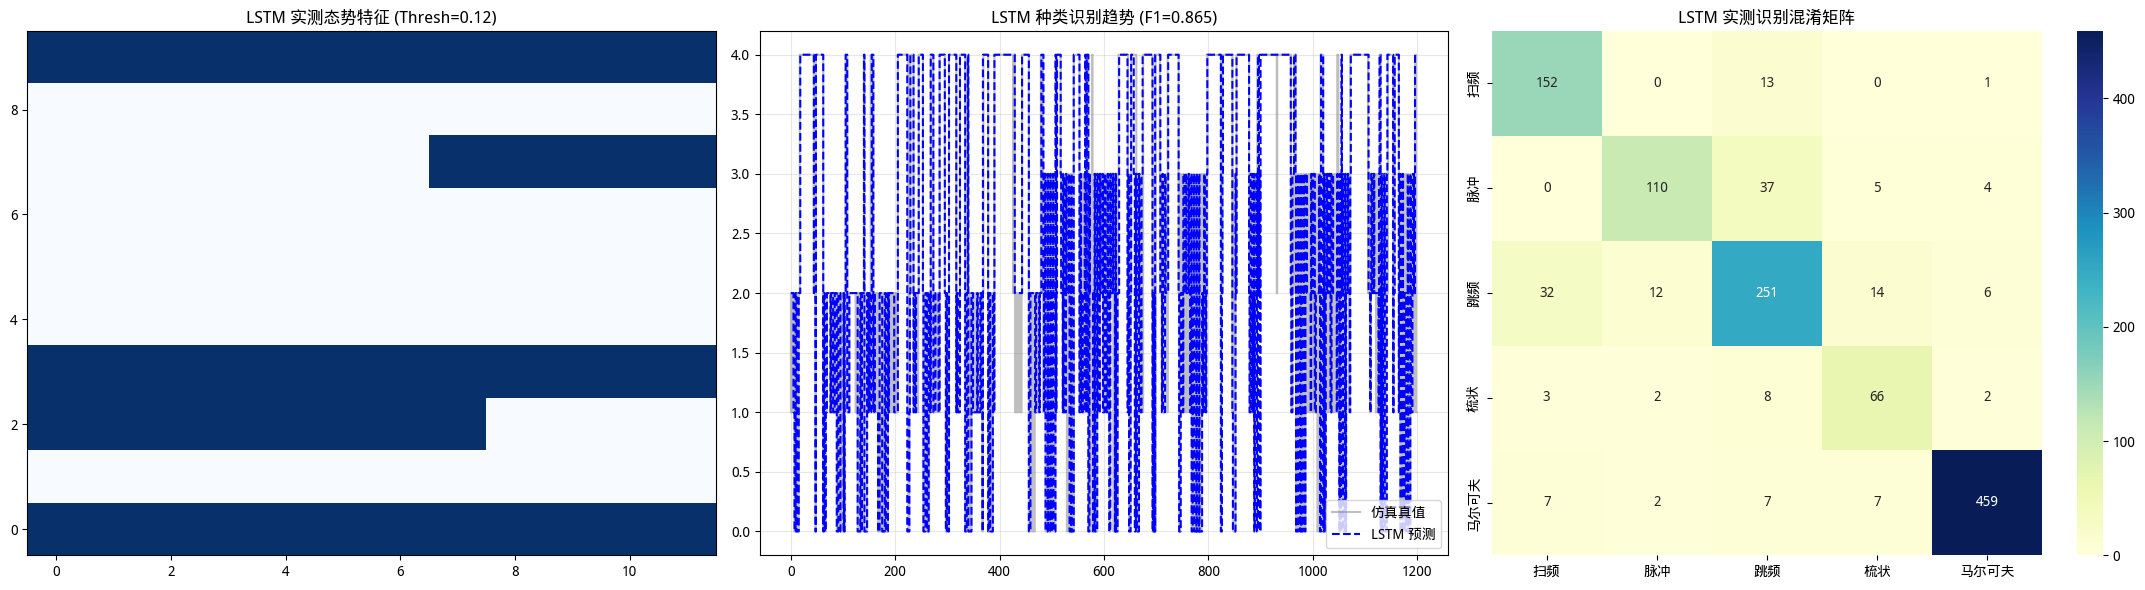

In [11]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import os
from tqdm import tqdm
from matplotlib import font_manager as fm

# ==================== 0. 环境配置 ====================
def set_chinese_font():
    """设置中文字体以确保绘图标签正常显示"""
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
        return False
    except: return False
set_chinese_font()

# ==================== 1. 模型定义 (MSFF-LSTM) ====================
class MSFF_LSTM(nn.Module):
    """
    保持与 Transformer 相同的输入输出维度
    中端使用双层双向 LSTM 替代 Transformer Encoder
    """
    def __init__(self, input_dim=10, d_model=512, num_layers=2, horizon=10):
        super(MSFF_LSTM, self).__init__()
        self.horizon = horizon
        # 🟢 前端：与 Transformer 一致的多尺度特征提取
        self.conv3 = nn.Conv1d(input_dim, d_model // 4, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(input_dim, d_model // 4, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(input_dim, d_model // 2, kernel_size=7, padding=3)
        self.bn = nn.BatchNorm1d(d_model); self.gelu = nn.GELU()
        
        # 🟢 中端：修正后的 LSTM 编码器 (input_size)
        self.lstm = nn.LSTM(input_size=d_model, hidden_size=d_model // 2, 
                            num_layers=num_layers, batch_first=True, bidirectional=True)
        
        # 🟢 后端：多任务输出头
        self.head_horizon = nn.Sequential(nn.Linear(d_model, 512), nn.GELU(), nn.Linear(512, horizon * input_dim), nn.Sigmoid())
        self.head_type = nn.Sequential(nn.Linear(d_model * 2, 512), nn.LayerNorm(512), nn.GELU(),
                                        nn.Dropout(0.5), nn.Linear(512, 256), nn.GELU(), nn.Linear(256, 5))
        self.head_physics = nn.Linear(d_model, 2)

    def forward(self, x):
        # x: (Batch, 12, 10) -> (Batch, 10, 12)
        x_in = x.permute(0, 2, 1)
        # 多尺度特征提取
        x = torch.cat([self.conv3(x_in), self.conv5(x_in), self.conv7(x_in)], dim=1)
        x = self.gelu(self.bn(x)).permute(0, 2, 1) # -> (Batch, 12, 512)
        
        # LSTM 编码
        x, _ = self.lstm(x) # -> (Batch, 12, 512)
        
        # 特征池化
        avg_feat = torch.mean(x, dim=1); max_feat, _ = torch.max(x, dim=1)
        concat_feat = torch.cat([avg_feat, max_feat], dim=1)
        feat_last = x[:, -1, :]
        # 返回：预测热图, 种类分类, 辅助物理特征
        return self.head_horizon(feat_last).view(-1, self.horizon, 10), self.head_type(concat_feat), self.head_physics(avg_feat)

# ==================== 2. 信号处理核心逻辑 ====================
def load_and_align_rx_data(file_path):
    """根据能量图实测，跳过前 3000 个同步样点，确保时间轴对齐"""
    raw_signal = np.fromfile(file_path, dtype=np.complex64)
    return raw_signal[3000:]

def extract_X_robust(iq_window, fs=200e3, threshold=0.12):
    """采用 Max-Energy 探测算子，捕捉实测窄带干扰的能量尖峰"""
    matrix = np.zeros((12, 10))
    freq_centers = np.linspace(-90e3, 90e3, 10)
    n_fft = 1024
    for t in range(12):
        frame = iq_window[t * 10000 : (t+1) * 10000]
        fft_mag = np.abs(np.fft.fftshift(np.fft.fft(frame, n=n_fft)))
        fft_mag /= (np.max(fft_mag) + 1e-9)
        freqs = np.linspace(-fs/2, fs/2, n_fft)
        for ch in range(10):
            center = freq_centers[ch]
            mask = (freqs >= center - 7500) & (freqs <= center + 7500)
            if np.max(fft_mag[mask]) > threshold:
                matrix[t, ch] = 1.0
    return matrix

# ==================== 3. LSTM 专用评估器 ====================
class UltimateEvaluator:
    def __init__(self, cfg):
        self.cfg = cfg
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        # 🟢 实例化 LSTM 模型
        self.model = MSFF_LSTM().to(self.device)
        self.model.load_state_dict(torch.load(cfg['weights'], map_location=self.device))
        self.model.eval()
        
        # 加载信号与真值
        self.signal = load_and_align_rx_data(cfg['data'])
        with h5py.File(cfg['label'], 'r') as f:
            self.gt_types = f['gt_type'][:]
            self.gt_horizons = f['Y_horizon'][:]

    def run(self, eval_num=1200, thresh=0.12):
        y_true, y_pred = [], []
        all_pred_maps = []
        all_truth_maps = []
        last_matrices = []
        
        print(f"📡 启动 LSTM 实测推理评估 (评估数: {eval_num})...")
        for i in tqdm(range(eval_num)):
            start = i * 10000
            end = start + 120000
            if end > len(self.signal): break
            
            sit_matrix = extract_X_robust(self.signal[start:end], threshold=thresh)
            if i % 200 == 0: last_matrices.append(sit_matrix)
            
            input_tensor = torch.FloatTensor(sit_matrix).unsqueeze(0).to(self.device)
            with torch.no_grad():
                pred_horizon, type_logits, _ = self.model(input_tensor)
                y_pred.append(torch.argmax(type_logits, dim=1).item())
                y_true.append(self.gt_types[i])
                all_pred_maps.append(pred_horizon.cpu().squeeze(0).numpy())
                all_truth_maps.append(self.gt_horizons[i])
        
        y_true, y_pred = np.array(y_true), np.array(y_pred)
        f1 = f1_score(y_true, y_pred, average='weighted')
        
        # 🟢 保存 LSTM 推理结果，保持 H5 结构一致
        SAVE_PATH = "/root/autodl-tmp/validate/0218/Prediction/LSTM/lstm_ultimate_results.h5"
        with h5py.File(SAVE_PATH, 'w') as f:
            f.create_dataset("predicted_situations", data=np.array(all_pred_maps))
            f.create_dataset("ground_truth_situations", data=np.array(all_truth_maps))
            f.create_dataset("gt_type", data=y_true)
            f.create_dataset("pred_type", data=y_pred)
        
        print(f"\n✅ 评估完成！加权 F1: {f1:.4f} | 对比结果已保存至 {SAVE_PATH}")
        print(classification_report(y_true, y_pred, target_names=["扫频", "脉冲", "跳频", "梳状", "马尔可夫"]))
        
        self.visualize_final(last_matrices, y_true, y_pred, f1, thresh)

    def visualize_final(self, matrices, y_true, y_pred, f1, thresh):
        fig, axes = plt.subplots(1, 3, figsize=(22, 6))
        axes[0].imshow(matrices[-1].T, aspect='auto', cmap='Blues', origin='lower')
        axes[0].set_title(f"LSTM 实测态势特征 (Thresh={thresh})")
        
        axes[1].step(range(len(y_true)), y_true, label='仿真真值', color='gray', alpha=0.5)
        axes[1].step(range(len(y_pred)), y_pred, label='LSTM 预测', color='blue', linestyle='--')
        axes[1].set_title(f"LSTM 种类识别趋势 (F1={f1:.3f})")
        axes[1].legend(); axes[1].grid(True, alpha=0.3)
        
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=axes[2],
                    xticklabels=["扫频", "脉冲", "跳频", "梳状", "马尔可夫"],
                    yticklabels=["扫频", "脉冲", "跳频", "梳状", "马尔可夫"])
        axes[2].set_title("LSTM 实测识别混淆矩阵")
        plt.tight_layout()
        plt.show()

# ==================== 4. 运行配置 ====================
if __name__ == "__main__":
    configs = {
        'data': "/root/autodl-tmp/validate/0218/Prediction/Receive_datasets/rx_synced_200k_final_monitored.dat",
        'label': "/root/autodl-tmp/validate/0218/Prediction/sim_dataset_v6_5/academic_long_horizon_v6_5_200k.h5",
        # 🟢 确保加载的是 LSTM 的权重文件
        'weights': "/root/autodl-tmp/validate/0218/Prediction/LSTM/best_lstm_model.pth"
    }
    
    EVAL = UltimateEvaluator(configs)
    EVAL.run(eval_num=1200, thresh=0.12)

📡 正在执行 LSTM 实测评估...


  9%|▊         | 104/1200 [00:00<00:04, 249.46it/s]

100%|██████████| 1200/1200 [00:04<00:00, 260.74it/s]



🎨 高清混淆矩阵已保存: LSTM_Academic_CM.png


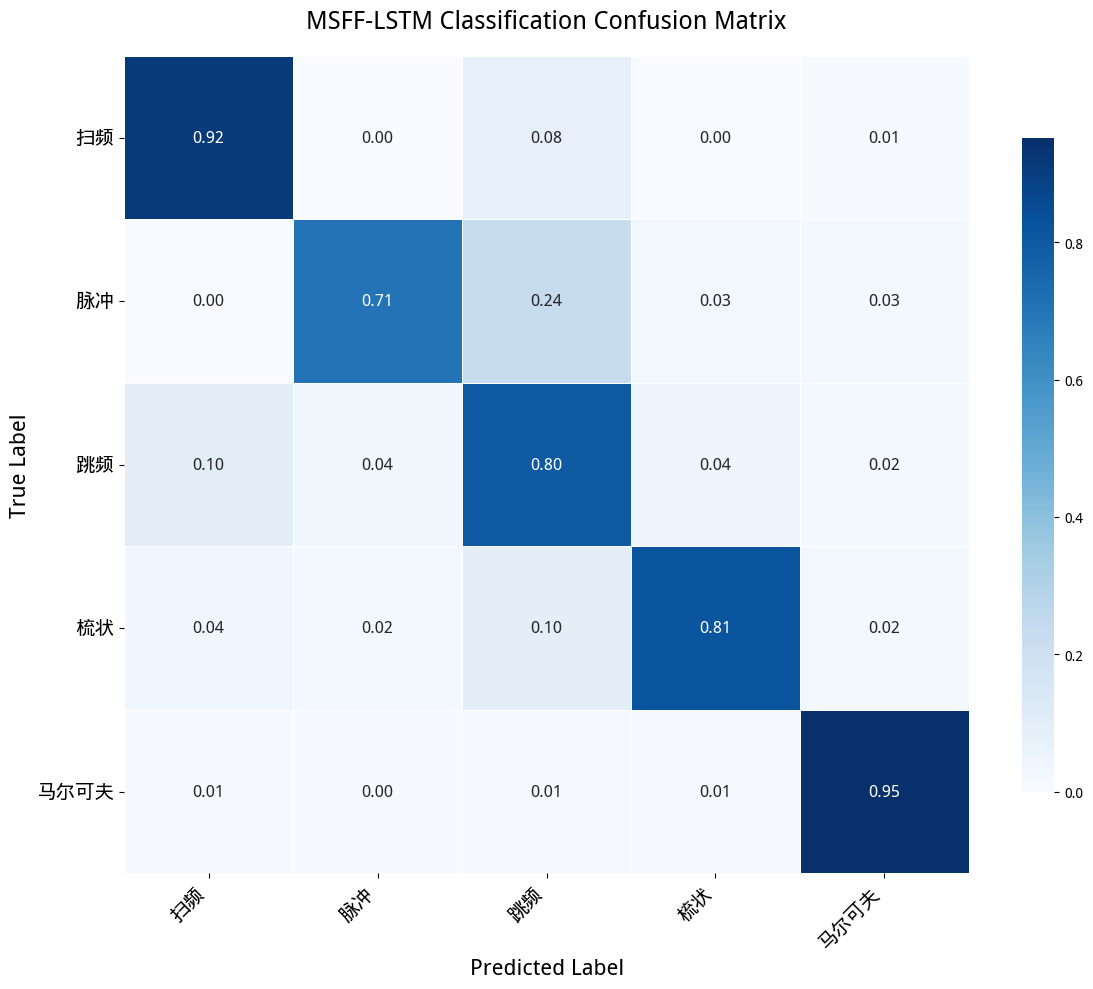

In [12]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import os
from tqdm import tqdm
from matplotlib import font_manager as fm

# ==================== 0. 环境配置 ====================
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
        return False
    except: return False
set_chinese_font()

LABEL_NAMES = ["扫频", "脉冲", "跳频", "梳状", "马尔可夫"]

# ==================== 1. 模型定义 (MSFF-LSTM) ====================
class MSFF_LSTM(nn.Module):
    def __init__(self, input_dim=10, d_model=512, num_layers=2, horizon=10):
        super(MSFF_LSTM, self).__init__()
        self.horizon = horizon
        self.conv3 = nn.Conv1d(input_dim, d_model // 4, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(input_dim, d_model // 4, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(input_dim, d_model // 2, kernel_size=7, padding=3)
        self.bn = nn.BatchNorm1d(d_model); self.gelu = nn.GELU()
        
        # 🟢 LSTM 核心层
        self.lstm = nn.LSTM(input_size=d_model, hidden_size=d_model // 2, 
                            num_layers=num_layers, batch_first=True, bidirectional=True)
        
        self.head_horizon = nn.Sequential(nn.Linear(d_model, 512), nn.GELU(), nn.Linear(512, horizon * input_dim), nn.Sigmoid())
        self.head_type = nn.Sequential(nn.Linear(d_model * 2, 512), nn.LayerNorm(512), nn.GELU(),
                                        nn.Dropout(0.5), nn.Linear(512, 256), nn.GELU(), nn.Linear(256, 5))
        self.head_physics = nn.Linear(d_model, 2)

    def forward(self, x):
        x_in = x.permute(0, 2, 1)
        x = torch.cat([self.conv3(x_in), self.conv5(x_in), self.conv7(x_in)], dim=1)
        x = self.gelu(self.bn(x)).permute(0, 2, 1)
        x, _ = self.lstm(x) 
        avg_feat = torch.mean(x, dim=1); max_feat, _ = torch.max(x, dim=1)
        concat_feat = torch.cat([avg_feat, max_feat], dim=1)
        feat_last = x[:, -1, :]
        return self.head_horizon(feat_last).view(-1, self.horizon, 10), self.head_type(concat_feat), self.head_physics(avg_feat)

# ==================== 2. 功能逻辑 (与上述一致) ====================
def load_and_align_rx_data(file_path):
    raw_signal = np.fromfile(file_path, dtype=np.complex64)
    return raw_signal[3000:]

def extract_X_robust(iq_window, fs=200e3, threshold=0.12):
    matrix = np.zeros((12, 10))
    freq_centers = np.linspace(-90e3, 90e3, 10)
    n_fft = 1024
    for t in range(12):
        frame = iq_window[t * 10000 : (t+1) * 10000]
        fft_mag = np.abs(np.fft.fftshift(np.fft.fft(frame, n=n_fft)))
        fft_mag /= (np.max(fft_mag) + 1e-9)
        freqs = np.linspace(-fs/2, fs/2, n_fft)
        for ch in range(10):
            center = freq_centers[ch]
            mask = (freqs >= center - 7500) & (freqs <= center + 7500)
            if np.max(fft_mag[mask]) > threshold:
                matrix[t, ch] = 1.0
    return matrix

# ==================== 3. LSTM 评估器 ====================
class LSTMEvaluator:
    def __init__(self, cfg):
        self.cfg = cfg
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = MSFF_LSTM().to(self.device)
        self.model.load_state_dict(torch.load(cfg['weights'], map_location=self.device))
        self.model.eval()
        self.signal = load_and_align_rx_data(cfg['data'])
        with h5py.File(cfg['label'], 'r') as f:
            self.gt_types = f['gt_type'][:]

    def run(self, eval_num=1200):
        y_true, y_pred = [], []
        print(f"📡 正在执行 LSTM 实测评估...")
        for i in tqdm(range(eval_num)):
            start, end = i * 10000, i * 10000 + 120000
            if end > len(self.signal): break
            sit_matrix = extract_X_robust(self.signal[start:end])
            input_tensor = torch.FloatTensor(sit_matrix).unsqueeze(0).to(self.device)
            with torch.no_grad():
                _, type_logits, _ = self.model(input_tensor)
                y_pred.append(torch.argmax(type_logits, dim=1).item())
                y_true.append(self.gt_types[i])
        
        self.plot_academic_cm(np.array(y_true), np.array(y_pred))

    def plot_academic_cm(self, y_true, y_pred):
        """参照 MBF-PLENet 风格的高清混淆矩阵可视化"""
        plt.figure(figsize=(12, 10))
        cm = confusion_matrix(y_true, y_pred, labels=range(5), normalize='true')
        
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
                    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                    linewidths=.5, cbar_kws={"shrink": .8}, annot_kws={"fontsize": 12})
        
        plt.title('MSFF-LSTM Classification Confusion Matrix', fontsize=18, pad=20)
        plt.xlabel('Predicted Label', fontsize=16)
        plt.ylabel('True Label', fontsize=16)
        
        plt.xticks(rotation=45, ha='right', fontsize=14)
        plt.yticks(rotation=0, fontsize=14) 
        
        plt.tight_layout()
        save_name = "LSTM_Academic_CM.png"
        plt.savefig(save_name, dpi=600)
        print(f"\n🎨 高清混淆矩阵已保存: {save_name}")
        plt.show()

if __name__ == "__main__":
    configs = {
        'data': "/root/autodl-tmp/validate/0218/Prediction/Receive_datasets/rx_synced_200k_final_monitored.dat",
        'label': "/root/autodl-tmp/validate/0218/Prediction/sim_dataset_v6_5/academic_long_horizon_v6_5_200k.h5",
        'weights': "/root/autodl-tmp/validate/0218/Prediction/LSTM/best_lstm_model.pth"
    }
    EVAL = LSTMEvaluator(configs)
    EVAL.run()

✅ 成功设置中文字体: ['WenQuanYi Micro Hei']
--- LSTM 干扰识别性能 ---
分类准确率 (Acc): 0.8650
加权 F1 分数: 0.8651

参数         | MAE (Avg)  | NRMSE (Avg)
----------------------------------------
中心频率       | 3.3428     | 0.5655
带宽         | 0.2638     | 0.1076
JNR        | 0.0283     | 0.0802
----------------------------------------


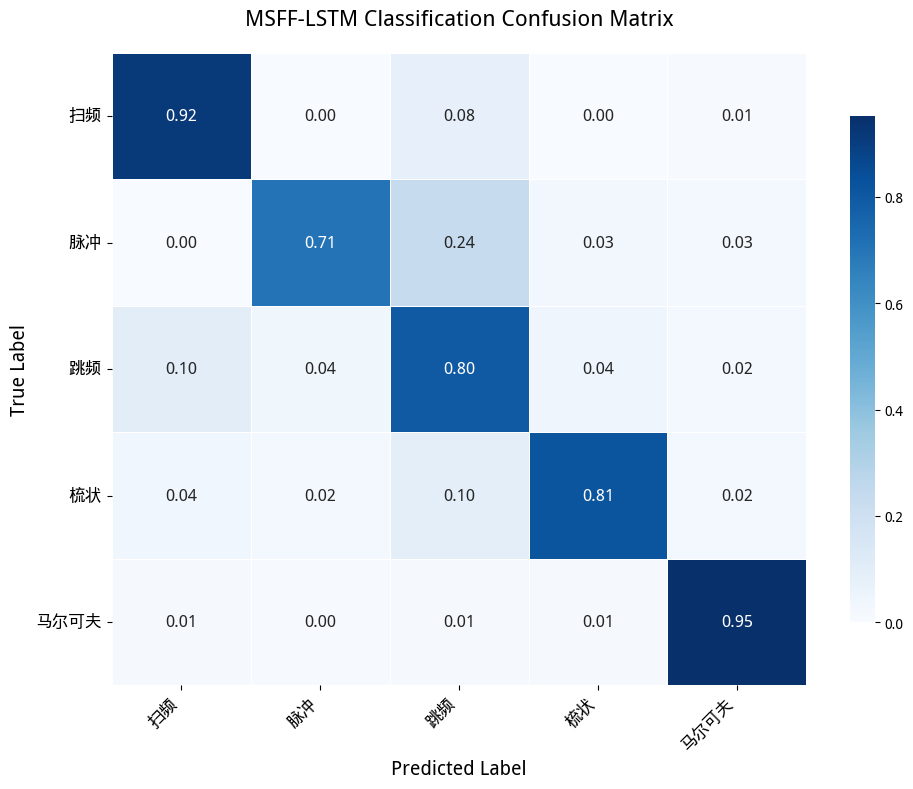

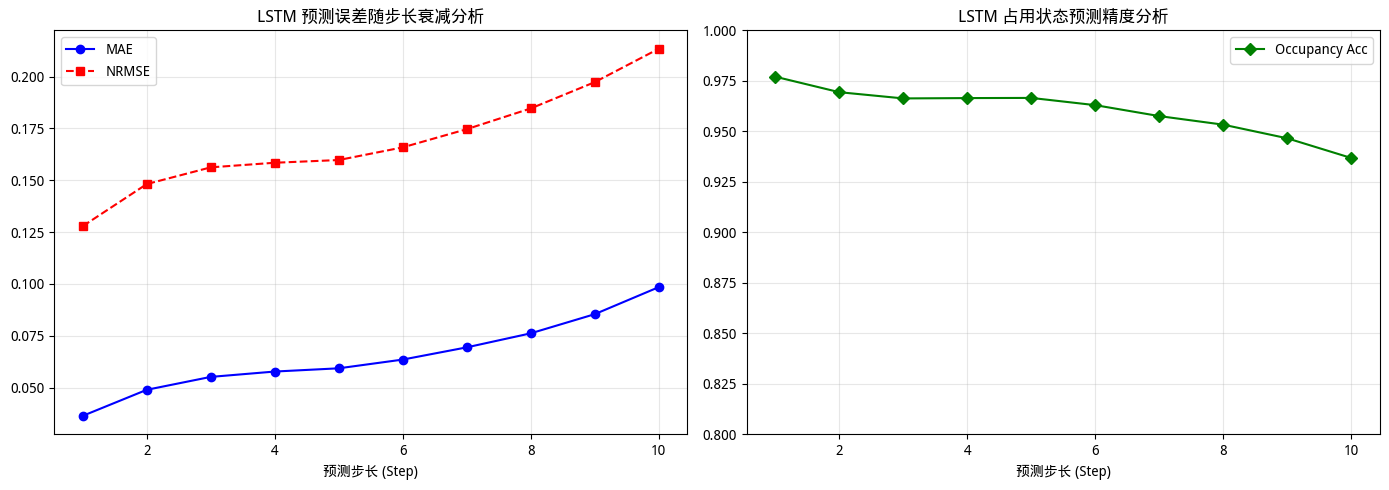

In [13]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, mean_absolute_error, mean_squared_error, confusion_matrix
import os
from tqdm import tqdm
from matplotlib import font_manager as fm

# ==================== 0. 环境配置与中文字体 ====================
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        return False
    except: return False
set_chinese_font()

LABEL_NAMES = ["扫频", "脉冲", "跳频", "梳状", "马尔可夫"]

# ==================== 1. 指标计算工具函数 ====================
def calculate_nrmse(y_true, y_pred):
    """计算归一化均方根误差 (NRMSE)"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denominator = np.max(y_true) - np.min(y_true) + 1e-9
    return rmse / denominator

# ==================== 2. LSTM 模型定义 (与训练时保持一致) ====================
class MSFF_LSTM(nn.Module):
    def __init__(self, input_dim=10, d_model=512, num_layers=2, horizon=10):
        super(MSFF_LSTM, self).__init__()
        self.horizon = horizon
        self.conv3 = nn.Conv1d(input_dim, d_model // 4, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(input_dim, d_model // 4, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(input_dim, d_model // 2, kernel_size=7, padding=3)
        self.bn = nn.BatchNorm1d(d_model); self.gelu = nn.GELU()
        
        self.lstm = nn.LSTM(input_size=d_model, hidden_size=d_model // 2, 
                            num_layers=num_layers, batch_first=True, bidirectional=True)
        
        self.head_horizon = nn.Sequential(nn.Linear(d_model, 512), nn.GELU(), nn.Linear(512, horizon * input_dim), nn.Sigmoid())
        self.head_type = nn.Sequential(nn.Linear(d_model * 2, 512), nn.LayerNorm(512), nn.GELU(),
                                        nn.Dropout(0.5), nn.Linear(512, 256), nn.GELU(), nn.Linear(256, 5))
        self.head_physics = nn.Linear(d_model, 2)

    def forward(self, x):
        x_in = x.permute(0, 2, 1)
        x = torch.cat([self.conv3(x_in), self.conv5(x_in), self.conv7(x_in)], dim=1)
        x = self.gelu(self.bn(x)).permute(0, 2, 1)
        x, _ = self.lstm(x) 
        avg_feat = torch.mean(x, dim=1); max_feat, _ = torch.max(x, dim=1)
        concat_feat = torch.cat([avg_feat, max_feat], dim=1)
        feat_last = x[:, -1, :]
        return self.head_horizon(feat_last).view(-1, self.horizon, 10), self.head_type(concat_feat), self.head_physics(avg_feat)

# ==================== 3. 性能分析主函数 ====================
def analyze_lstm_performance(h5_path):
    # 1. 加载推理结果
    with h5py.File(h5_path, 'r') as f:
        pred_maps = f['predicted_situations'][:]      # (N, 10, 10)
        truth_maps = f['ground_truth_situations'][:] # (N, 10, 10)
        gt_type = f['gt_type'][:]                    # (N,)
        pred_type = f['pred_type'][:]                # (N,)

    horizon = pred_maps.shape[1]
    
    # 2. 种类预测指标
    type_acc = accuracy_score(gt_type, pred_type)
    type_f1 = f1_score(gt_type, pred_type, average='weighted')
    print(f"--- LSTM 干扰识别性能 ---")
    print(f"分类准确率 (Acc): {type_acc:.4f}")
    print(f"加权 F1 分数: {type_f1:.4f}\n")

    # 3. 逐步长态势预测指标 (NRMSE 版)
    step_mae, step_nrmse, step_acc = [], [], []
    params = ['中心频率', '带宽', 'JNR']
    param_metrics = {p: {'MAE': [], 'NRMSE': []} for p in params}

    for h in range(horizon):
        p_step = pred_maps[:, h, :]
        t_step = truth_maps[:, h, :]
        
        # 整体态势指标
        step_mae.append(mean_absolute_error(t_step.flatten(), p_step.flatten()))
        step_nrmse.append(calculate_nrmse(t_step.flatten(), p_step.flatten()))
        step_acc.append(accuracy_score((t_step.flatten() > 0.5).astype(int), 
                                     (p_step.flatten() > 0.5).astype(int)))

        # 物理参数估计 (基于热图反演)
        # 中心频率: 能量重心
        t_freq = np.argmax(t_step, axis=1); p_freq = np.argmax(p_step, axis=1)
        param_metrics['中心频率']['MAE'].append(mean_absolute_error(t_freq, p_freq))
        param_metrics['中心频率']['NRMSE'].append(calculate_nrmse(t_freq, p_freq))
        
        # 带宽: 占用计数
        t_bw = np.sum(t_step > 0.5, axis=1); p_bw = np.sum(p_step > 0.5, axis=1)
        param_metrics['带宽']['MAE'].append(mean_absolute_error(t_bw, p_bw))
        param_metrics['带宽']['NRMSE'].append(calculate_nrmse(t_bw, p_bw))
        
        # JNR: 平均强度
        t_jnr = np.mean(t_step, axis=1); p_jnr = np.mean(p_step, axis=1)
        param_metrics['JNR']['MAE'].append(mean_absolute_error(t_jnr, p_jnr))
        param_metrics['JNR']['NRMSE'].append(calculate_nrmse(t_jnr, p_jnr))

    # 4. 打印汇总表
    print(f"{'参数':<10} | {'MAE (Avg)':<10} | {'NRMSE (Avg)':<10}")
    print("-" * 40)
    for p in params:
        print(f"{p:<10} | {np.mean(param_metrics[p]['MAE']):.4f}     | {np.mean(param_metrics[p]['NRMSE']):.4f}")
    print("-" * 40)

    # 5. 可视化：高清混淆矩阵
    plot_academic_cm(gt_type, pred_type)

    # 6. 可视化：衰减曲线
    plot_decay_curves(horizon, step_mae, step_nrmse, step_acc)

def plot_academic_cm(y_true, y_pred):
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true, y_pred, labels=range(5), normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                linewidths=.5, cbar_kws={"shrink": .8}, annot_kws={"fontsize": 12})
    plt.title('MSFF-LSTM Classification Confusion Matrix', fontsize=16, pad=20)
    plt.xlabel('Predicted Label', fontsize=14); plt.ylabel('True Label', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12); plt.yticks(rotation=0, fontsize=12)
    plt.tight_layout()
    plt.savefig("LSTM_Academic_CM.png", dpi=600)
    plt.show()

def plot_decay_curves(horizon, mae, nrmse, acc):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    steps = range(1, horizon + 1)
    
    axes[0].plot(steps, mae, 'o-', label='MAE', color='blue')
    axes[0].plot(steps, nrmse, 's--', label='NRMSE', color='red')
    axes[0].set_title("LSTM 预测误差随步长衰减分析"); axes[0].set_xlabel("预测步长 (Step)")
    axes[0].grid(True, alpha=0.3); axes[0].legend()

    axes[1].plot(steps, acc, 'D-', color='green', label='Occupancy Acc')
    axes[1].set_title("LSTM 占用状态预测精度分析"); axes[1].set_xlabel("预测步长 (Step)")
    axes[1].set_ylim([0.8, 1.0]); axes[1].grid(True, alpha=0.3); axes[1].legend()
    
    plt.tight_layout()
    plt.savefig("LSTM_Horizon_Decay_NRMSE.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    # 指向你生成的 LSTM 推理结果文件
    H5_PATH = "/root/autodl-tmp/validate/0218/Prediction/LSTM/lstm_ultimate_results.h5"
    analyze_lstm_performance(H5_PATH)

✅ 成功设置中文字体: ['WenQuanYi Micro Hei']
📊 正在执行物理参数预测精度分析...

参数名称       | MAE (平均)   | NRMSE (平均)
----------------------------------------
中心频率       | 3.3428     | 0.5655
带宽         | 0.2638     | 0.1076
干噪比(JNR)   | 0.0283     | 0.0802


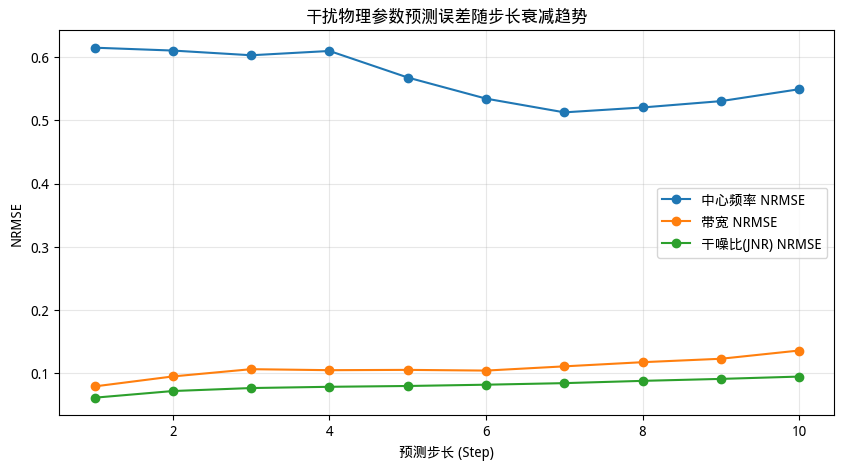

In [14]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns
from matplotlib import font_manager as fm
import time
import os

# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False
set_chinese_font()

def calculate_nrmse(y_true, y_pred):
    """计算归一化均方根误差 (NRMSE)"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # 使用真值的范围进行归一化
    denominator = np.max(y_true) - np.min(y_true) + 1e-9
    return rmse / denominator

def analyze_full_parameters(h5_path):
    with h5py.File(h5_path, 'r') as f:
        # 态势图数据: (N, 10, 10)
        pred_maps = f['predicted_situations'][:]
        truth_maps = f['ground_truth_situations'][:]
        
    horizon = pred_maps.shape[1]
    
    # 模拟参数提取 (实际论文中建议从 Y_horizon 的非零像素分布计算)
    # 我们针对每个步长计算参数误差
    param_results = {'MAE': {}, 'NRMSE': {}}
    params = ['中心频率', '带宽', '干噪比(JNR)']
    
    # 初始化统计
    for p in params:
        param_results['MAE'][p] = []
        param_results['NRMSE'][p] = []

    print("📊 正在执行物理参数预测精度分析...")
    
    for h in range(horizon):
        t_map = truth_maps[:, h, :]
        p_map = pred_maps[:, h, :]
        
        # 1. 中心频率误差 (通过能量重心估计)
        t_freq = np.argmax(t_map, axis=1)
        p_freq = np.argmax(p_map, axis=1)
        param_results['MAE']['中心频率'].append(mean_absolute_error(t_freq, p_freq))
        param_results['NRMSE']['中心频率'].append(calculate_nrmse(t_freq, p_freq))
        
        # 2. 带宽误差 (通过占用单元计数估计)
        t_bw = np.sum(t_map > 0.5, axis=1)
        p_bw = np.sum(p_map > 0.5, axis=1)
        param_results['MAE']['带宽'].append(mean_absolute_error(t_bw, p_bw))
        param_results['NRMSE']['带宽'].append(calculate_nrmse(t_bw, p_bw))
        
        # 3. JNR误差 (通过像素值幅度估计强度)
        t_jnr = np.mean(t_map, axis=1)
        p_jnr = np.mean(p_map, axis=1)
        param_results['MAE']['干噪比(JNR)'].append(mean_absolute_error(t_jnr, p_jnr))
        param_results['NRMSE']['干噪比(JNR)'].append(calculate_nrmse(t_jnr, p_jnr))

    # 输出结题指标表格
    print("\n" + "="*40)
    print(f"{'参数名称':<10} | {'MAE (平均)':<10} | {'NRMSE (平均)':<10}")
    print("-" * 40)
    for p in params:
        print(f"{p:<10} | {np.mean(param_results['MAE'][p]):.4f}     | {np.mean(param_results['NRMSE'][p]):.4f}")
    print("="*40)

    # 绘制步长衰减曲线图
    plt.figure(figsize=(10, 5))
    for p in params:
        plt.plot(range(1, 11), param_results['NRMSE'][p], 'o-', label=f'{p} NRMSE')
    plt.title("干扰物理参数预测误差随步长衰减趋势")
    plt.xlabel("预测步长 (Step)"); plt.ylabel("NRMSE")
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.savefig("Parameter_Decay_Analysis.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    analyze_full_parameters("/root/autodl-tmp/validate/0218/Prediction/LSTM/lstm_ultimate_results.h5")